# Task 1.2 - mixed-variable pure PINN v2 upstream refinement

This notebook starts from the completed **physics-only v1 training checkpoint**,
changes the inlet hard transform so velocity corrections can develop rapidly, and
performs a fresh full-Re500 physics refinement. The v1 optimizer is not restored.

The v1 result is preserved separately. V2 writes to a new output directory. It
uses no CFD velocity or pressure labels in its loss, RAR, checkpoint selection,
or stopping. Five OpenFOAM profiles are loaded only after the refined model is
frozen. Fourier features remain OFF.

The architectural change targets the identified expressiveness restriction:
`x/L` allowed only 16% correction at x=15 mm and 39% at x=36 mm. The new smooth
inlet ramp remains zero at the inlet but supplies about 87% and 99% correction
freedom at those locations.


In [1]:
# GPU environment - tuned for a Kaggle NVIDIA T4 without reinstalling PyTorch.
import gc, hashlib, inspect, json, math, os, random, shutil, subprocess, sys, time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm.auto import trange

SEED = 20260916
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
ALLOW_CPU_SMOKE = os.getenv("RHEOLNET_ALLOW_CPU_SMOKE", "0") == "1"
if not torch.cuda.is_available() and not ALLOW_CPU_SMOKE:
    raise RuntimeError("CUDA unavailable. In Kaggle select Accelerator -> GPU T4, restart, then run all.")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
if device.type == "cuda":
    GPU_NAME = torch.cuda.get_device_name(0)
    GPU_CAPABILITY = torch.cuda.get_device_capability(0)
    print("GPU:", GPU_NAME, "| capability:", GPU_CAPABILITY,
          "| torch:", torch.__version__, "| CUDA:", torch.version.cuda)
    if "T4" not in GPU_NAME.upper(): print("WARNING: schedule is tuned for a T4.")
    if GPU_CAPABILITY < (7, 5): raise RuntimeError("T4-class sm_75 or newer GPU required.")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    GPU_NAME, GPU_CAPABILITY = "CPU smoke test", None
print("mixed-PINN derivative dtype:", DTYPE, "| device:", device)


GPU: Tesla T4 | capability: (7, 5) | torch: 2.10.0+cu128 | CUDA: 12.8
mixed-PINN derivative dtype: torch.float32 | device: cuda:0


In [2]:
# Reproducible repository setup. PyTorch is preinstalled on Kaggle.
REPO_DIR = Path("/kaggle/working/RheolNet")
BRANCH = "Atharva_pinn-core-baseline"
REPOSITORY_URL = "https://github.com/ath4trva/RheolNet.git"
if not REPO_DIR.exists():
    subprocess.check_call(["git", "clone", "--branch", BRANCH, "--single-branch", REPOSITORY_URL, str(REPO_DIR)])
else:
    subprocess.check_call(["git", "pull", "--ff-only", "origin", BRANCH], cwd=REPO_DIR)
if str(REPO_DIR) in sys.path: sys.path.remove(str(REPO_DIR))
sys.path.insert(0, str(REPO_DIR))
import importlib
for module_name in list(sys.modules):
    if module_name in {"geometry", "cfd", "validation"} or module_name.startswith(("geometry.", "cfd.", "validation.")):
        del sys.modules[module_name]
importlib.invalidate_caches()
COMMIT = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_DIR, text=True).strip()

from geometry.planar_stenosis_sampling import (
    sample_interior_points, sample_wall_points, sample_inlet_points, sample_outlet_points,
)
try:
    from cfd.planar_stenosis_cfd import load_planar_stenosis_case, validate_planar_stenosis_case
    CFD_MODULE_LAYOUT = "canonical cfd/"
except ModuleNotFoundError:
    from geometry.planar_stenosis_cfd import load_planar_stenosis_case, validate_planar_stenosis_case
    CFD_MODULE_LAYOUT = "legacy geometry/ fallback"
try:
    from validation.planar_stenosis_metrics import relative_l2_error, evaluate_planar_stenosis_field
    VALIDATION_MODULE_LAYOUT = "canonical validation/"
except ModuleNotFoundError:
    from geometry.planar_stenosis_metrics import relative_l2_error, evaluate_planar_stenosis_field
    VALIDATION_MODULE_LAYOUT = "legacy geometry/ fallback"

print("branch:", BRANCH); print("commit:", COMMIT)
print("CFD loader:", CFD_MODULE_LAYOUT, "| metrics:", VALIDATION_MODULE_LAYOUT)
for obj in (sample_interior_points, load_planar_stenosis_case, relative_l2_error):
    print(f"{obj.__name__:38s} {inspect.getfile(obj)}")


Cloning into '/kaggle/working/RheolNet'...


branch: Atharva_pinn-core-baseline
commit: 6e5ebcd77cf620a1072da166a5faba426c1d277a
CFD loader: legacy geometry/ fallback | metrics: legacy geometry/ fallback
sample_interior_points                 /kaggle/working/RheolNet/geometry/planar_stenosis_sampling.py
load_planar_stenosis_case              /kaggle/working/RheolNet/geometry/planar_stenosis_cfd.py
relative_l2_error                      /kaggle/working/RheolNet/geometry/planar_stenosis_metrics.py


In [3]:
# Flattened Kaggle dataset -> canonical RheolNet case layout.
DATASET_ROOT = Path("/kaggle/input/datasets/nightfury22344/p2d-st40-re500")
ST40_DIR = Path("/kaggle/working/P2D_ST40_Re500")
OUTPUT_DIR = Path("/kaggle/working/task_1_2_st40_mixed_pinn_v2")
for sub in ("checkpoints", "figures", "metrics", "logs"):
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

required = {
    "case_metadata.json": "case_metadata.json",
    "full_field.csv": "full_field.csv",
    "mesh_independence.csv": "mesh_independence.csv",
    "blockMeshDict": "OpenFOAM_case/system/blockMeshDict",
    "U": "OpenFOAM_case/0/U",
}
missing = [name for name in required if not (DATASET_ROOT / name).is_file()]
if missing: raise FileNotFoundError(f"Missing flattened dataset files: {missing}")
for src, dst in required.items():
    target = ST40_DIR / dst; target.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(DATASET_ROOT / src, target)
profile_sources = sorted(DATASET_ROOT.glob("profile_*.csv"))
if len(profile_sources) != 5: raise RuntimeError(f"Expected five profile files, found {len(profile_sources)}")
profile_dir = ST40_DIR / "velocity_profiles"; profile_dir.mkdir(parents=True, exist_ok=True)
for path in profile_sources: shutil.copy2(path, profile_dir / path.name)
print("case:", ST40_DIR); print("outputs:", OUTPUT_DIR)


case: /kaggle/working/P2D_ST40_Re500
outputs: /kaggle/working/task_1_2_st40_mixed_pinn_v2


,value
n_field_points,110400
n_unique_coordinates,110400
n_streamwise_locations,920
min_points_per_streamwise_location,120
max_points_per_streamwise_location,120
all_points_inside_geometry,True
inlet_profile_points,120


,field,minimum,maximum
0,u,-0.001362,0.599952
1,v,-0.026676,0.026676
2,p,-52.070774,80.434425
3,viscosity,0.003687,0.049159


,mesh,cells,Umax_m_s,pMin,pMax,nuMin_m2_s,nuMax_m2_s,nuAvg_m2_s,Qin_m3_s,Qout_m3_s,convergence_iteration,throat_centreline_Ux_m_s,medium_to_fine_throat_change_percent,grid_independence_result
0,coarse,6900,0.599826,-0.048957,0.076320,0.000004,0.000023,0.000005,1.651922e-07,1.651922e-07,628,0.587619,NaN,NaN
1,medium,27600,0.599936,-0.049192,0.075981,0.000003,0.000032,0.000005,1.651200e-07,1.651200e-07,947,0.588191,NaN,NaN
2,fine,110400,0.599952,-0.049123,0.075882,0.000003,0.000046,0.000005,1.651020e-07,1.651020e-07,1716,0.588328,0.023302,PASS (<2% medium-to-fine throat-centreline vel...


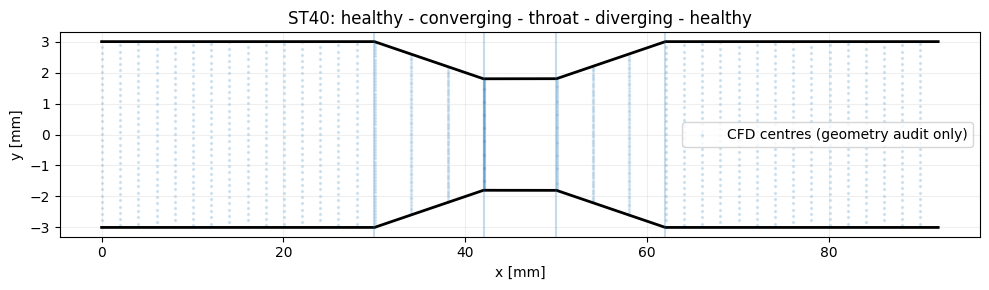

CFD solution arrays removed from memory. Training retains only metadata, geometry and inlet BC.


In [4]:
# Read-only CFD/reference audit. No solution value survives into training.
audit_case = load_planar_stenosis_case(ST40_DIR)
audit_summary = validate_planar_stenosis_case(audit_case)
metadata = json.loads(json.dumps(audit_case.metadata))
geometry = audit_case.geometry
inlet_y = audit_case.inlet_profile.y_m.copy()
inlet_u = audit_case.inlet_profile.u_m_s.copy()
inlet_v = audit_case.inlet_profile.v_m_s.copy()
mesh_table = pd.read_csv(ST40_DIR / "mesh_independence.csv")
profile_paths = sorted((ST40_DIR / "velocity_profiles").glob("profile_*.csv"))

assert audit_summary.n_field_points == 110_400
assert audit_summary.n_unique_coordinates == 110_400
assert audit_summary.n_streamwise_locations == 920
assert audit_summary.min_points_per_streamwise_location == 120
assert audit_summary.max_points_per_streamwise_location == 120
assert audit_summary.inlet_profile_points == 120 and len(profile_paths) == 5
assert abs(geometry.severity_percent - 40.0) < 0.1
assert mesh_table.loc[mesh_table["mesh"] == "fine", "medium_to_fine_throat_change_percent"].iloc[0] < 2.0

field_ranges = pd.DataFrame({
    "field": ["u", "v", "p", "viscosity"],
    "minimum": [audit_case.field.u_m_s.min(), audit_case.field.v_m_s.min(),
                audit_case.field.pressure_pa.min(), audit_case.field.viscosity_pa_s.min()],
    "maximum": [audit_case.field.u_m_s.max(), audit_case.field.v_m_s.max(),
                audit_case.field.pressure_pa.max(), audit_case.field.viscosity_pa_s.max()],
})
display(pd.DataFrame([audit_summary.__dict__]).T.rename(columns={0: "value"}))
display(field_ranges); display(mesh_table)

x_geom = np.linspace(0, geometry.total_length_m, 1200)
h_geom = geometry.half_height(x_geom)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x_geom*1e3, h_geom*1e3, "k", lw=2); ax.plot(x_geom*1e3, -h_geom*1e3, "k", lw=2)
ax.scatter(audit_case.field.x_m[::80]*1e3, audit_case.field.y_m[::80]*1e3, s=2, alpha=.15,
           label="CFD centres (geometry audit only)")
for x in (0.030, 0.042, 0.050, 0.062): ax.axvline(x*1e3, color="tab:blue", alpha=.25)
ax.set(xlabel="x [mm]", ylabel="y [mm]", title="ST40: healthy - converging - throat - diverging - healthy")
ax.grid(alpha=.2); ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR/"figures"/"st40_geometry.png", dpi=170); plt.show()

# Remove all internal CFD solution arrays before model construction/training.
CFD_AUDIT_COMPLETE = True
del audit_case, field_ranges
gc.collect()
print("CFD solution arrays removed from memory. Training retains only metadata, geometry and inlet BC.")


## Mixed first-order Carreau-Yasuda formulation

The network predicts velocity, pressure, and three independent viscous stresses.
The enforced equations are

\[
u_x+v_y=0,
\quad \rho(u u_x+v u_y)+p_x-(\tau_{xx})_x-(\tau_{xy})_y=0,
\]
\[
\rho(u v_x+v v_y)+p_y-(\tau_{xy})_x-(\tau_{yy})_y=0,
\]
\[
\tau_{xx}=2\mu u_x,\quad
\tau_{xy}=\mu(u_y+v_x),\quad
\tau_{yy}=2\mu v_y.
\]

Here `mu` is the Carreau-Yasuda viscosity evaluated from
`sqrt(2 ux^2 + 2 vy^2 + (uy+vx)^2)`. Every residual therefore uses only
first derivatives of a network output.


In [5]:
# Permitted physical inputs and dimensional residual scales.
rho = float(metadata["density_kg_m3"])
cy = metadata["bird_carreau"]
ETA0, ETA_INF = float(cy["mu0_Pa_s"]), float(cy["muInf_Pa_s"])
LAM, POWER_N, YASUDA_A = float(cy["lambda_s"]), float(cy["n"]), float(cy["a"])
L = float(geometry.total_length_m)
H = float(geometry.healthy_half_height_m)
HT = float(geometry.throat_half_height_m)
U = float(metadata["mean_inlet_velocity_m_s"])
V_SCALE = U * H / L
MU_REF = math.sqrt(ETA0 * ETA_INF)
P_SCALE = rho * U**2
TAU_SCALE = MU_REF * U / H
CONT_SCALE = U / L + V_SCALE / H
FORCE_SCALE = rho * U**2 / L + TAU_SCALE / H
Q_TARGET = 2.0 * H * U
physical = dict(rho=rho, mu0=ETA0, muInf=ETA_INF, lambda_s=LAM,
                n=POWER_N, a=YASUDA_A, L_m=L, H_m=H,
                throat_half_height_m=HT, U_m_s=U, V_scale=V_SCALE,
                pressure_scale_pa=P_SCALE, stress_scale_pa=TAU_SCALE,
                target_flow_m2_s=Q_TARGET)
display(pd.DataFrame([physical]).T.rename(columns={0: "value"}))


,value
rho,1060.000000
mu0,0.056000
muInf,0.003500
lambda_s,3.313000
n,0.356800
a,2.000000
L_m,0.092000
H_m,0.003000
throat_half_height_m,0.001800
U_m_s,0.275160


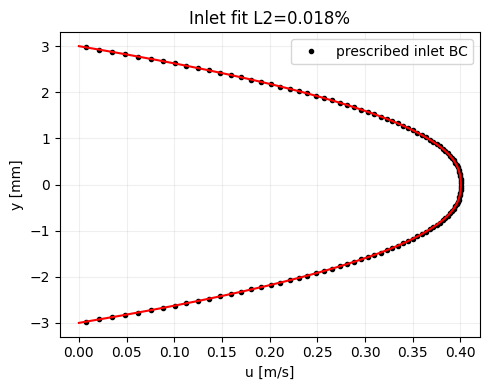

In [6]:
# High-accuracy representation of the prescribed inlet boundary condition.
from numpy.polynomial import chebyshev as cheb
inlet_eta = inlet_y / H
degree = 20
basis = cheb.chebvander(inlet_eta, degree) * (1.0 - inlet_eta**2)[:, None]
coefficients = np.linalg.lstsq(basis, inlet_u, rcond=None)[0]
u_coeff = cheb.chebmul(coefficients, np.array([0.5, 0.0, -0.5]))
integral = cheb.chebint(u_coeff)
raw_mean = 0.5 * (cheb.chebval(1.0, integral) - cheb.chebval(-1.0, integral))
u_coeff *= U / raw_mean
inlet_fit = cheb.chebval(inlet_eta, u_coeff)
inlet_fit_l2 = relative_l2_error(inlet_fit, inlet_u)
assert inlet_fit_l2 < 5e-3
assert abs(cheb.chebval(-1.0, u_coeff)) < 1e-10
assert abs(cheb.chebval(1.0, u_coeff)) < 1e-10
U_COEFFS = torch.tensor((u_coeff / U).astype(np.float32), device=device)

def cheb_eval(x, coefficients):
    b1, b2 = torch.zeros_like(x), torch.zeros_like(x)
    for coefficient in torch.flip(coefficients, dims=[0]):
        b2, b1 = b1, 2.0*x*b1 - b2 + coefficient
    return b1 - x*b2

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(inlet_u, inlet_y*1e3, "k.", label="prescribed inlet BC")
eta_plot = np.linspace(-1,1,401)
ax.plot(cheb.chebval(eta_plot,u_coeff), eta_plot*H*1e3, "r-")
ax.set(xlabel="u [m/s]", ylabel="y [mm]", title=f"Inlet fit L2={100*inlet_fit_l2:.3f}%")
ax.grid(alpha=.2); ax.legend(); fig.tight_layout(); plt.show()


In [7]:
# Exact CFD geometry for boundary transforms; softly smoothed copy only for network coordinates.
X1, X2, X3, X4 = 0.030, 0.042, 0.050, 0.062
CORNERS = torch.tensor([X1,X2,X3,X4], device=device, dtype=DTYPE)
CORNER_GUARD = 2.5e-4

def h_exact(x):
    h = torch.full_like(x, H)
    h = torch.where((x>=X1)&(x<X2), H+(HT-H)*(x-X1)/(X2-X1), h)
    h = torch.where((x>=X2)&(x<=X3), torch.full_like(h,HT), h)
    h = torch.where((x>X3)&(x<=X4), HT+(H-HT)*(x-X3)/(X4-X3), h)
    return h

SMOOTH_EPS = 2.0e-5
def smooth_relu(z):
    return torch.nn.functional.softplus(z/SMOOTH_EPS)*SMOOTH_EPS

def h_smooth(x):
    down = (HT-H)/(X2-X1) * (smooth_relu(x-X1)-smooth_relu(x-X2))
    up = (H-HT)/(X4-X3) * (smooth_relu(x-X3)-smooth_relu(x-X4))
    return H + down + up

def hprime_exact(x):
    slope = torch.zeros_like(x)
    slope = torch.where((x>=X1)&(x<X2), (HT-H)/(X2-X1), slope)
    slope = torch.where((x>X3)&(x<=X4), (H-HT)/(X4-X3), slope)
    return slope

def corner_safe(x):
    return (x.reshape(-1,1)-CORNERS.reshape(1,-1)).abs().min(dim=1).values > CORNER_GUARD

INLET_RAMP_LENGTH = 0.08 * L

class MixedStenosisPINN(nn.Module):
    def __init__(self, width=128, depth=5):
        super().__init__()
        layers=[]; in_features=2
        for _ in range(depth):
            layer=nn.Linear(in_features,width)
            nn.init.xavier_normal_(layer.weight); nn.init.zeros_(layer.bias)
            layers += [layer,nn.Tanh()]; in_features=width
        final=nn.Linear(width,6)
        nn.init.zeros_(final.weight); nn.init.zeros_(final.bias)
        layers.append(final); self.net=nn.Sequential(*layers)

    def forward(self, xy):
        x,y=xy[:,:1],xy[:,1:2]
        he=h_exact(x); hs=h_smooth(x)
        eta_wall=y/he
        inputs=torch.cat((2.0*x/L-1.0, y/hs),dim=1)
        raw=self.net(inputs)
        s=x/L; wall=1.0-eta_wall.square()
        inlet_ramp=1.0-torch.exp(-x/INLET_RAMP_LENGTH)
        base=U*(H/he)*cheb_eval(eta_wall,U_COEFFS)
        u=base+inlet_ramp*wall*U*raw[:,:1]
        v=inlet_ramp*wall*V_SCALE*raw[:,1:2]
        p=(1.0-s)*P_SCALE*raw[:,2:3]
        stresses=TAU_SCALE*raw[:,3:6]
        return torch.cat((u,v,p,stresses),dim=1)

model=MixedStenosisPINN(width=128,depth=5).to(device=device,dtype=DTYPE)
assert not any("fourier" in module.__class__.__name__.lower() for module in model.modules())
print(model); print("parameters:",sum(p.numel() for p in model.parameters()))
print("outputs: u, v, p, tau_xx, tau_xy, tau_yy | fast inlet ramp | Fourier features: OFF")


MixedStenosisPINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=6, bias=True)
  )
)
parameters: 67206
outputs: u, v, p, tau_xx, tau_xy, tau_yy | fast inlet ramp | Fourier features: OFF


In [8]:
# V2 sampling: global coverage plus strong upstream/converging-section coverage.
def accepted_project_points(n):
    chunks=[]; remaining=int(n)
    while remaining:
        points=sample_interior_points(geometry,max(2*remaining,512),device=device,dtype=DTYPE)
        points=points[corner_safe(points[:,0])]
        take=min(remaining,len(points));chunks.append(points[:take]);remaining-=take
    return torch.cat(chunks,dim=0)

def region_points(n):
    chunks=[]; remaining=int(n)
    while remaining:
        m=max(2*remaining,512)
        ng=int(.25*m); nu=int(.45*m); nc=m-ng-nu
        x=torch.cat((
            L*torch.rand((ng,1),device=device,dtype=DTYPE),
            .006+(.045-.006)*torch.rand((nu,1),device=device,dtype=DTYPE),
            .028+(.043-.028)*torch.rand((nc,1),device=device,dtype=DTYPE),
        ),dim=0)
        x=x[corner_safe(x[:,0])];take=min(remaining,len(x));chunks.append(x[:take]);remaining-=take
    x=torch.cat(chunks,dim=0)
    uniform=2.0*torch.rand_like(x)-1.0
    z=torch.rand_like(x);sign=torch.where(torch.rand_like(x)<.5,-torch.ones_like(x),torch.ones_like(x))
    near_wall=sign*(1.0-z.pow(3))
    eta=torch.where(torch.rand_like(x)<.35,near_wall,uniform).clamp(-.995,.995)
    points=torch.cat((x,eta*h_exact(x)),dim=1)
    return points[torch.randperm(len(points),device=device)]

wall_bottom,wall_top=sample_wall_points(geometry,1200,device=device,dtype=DTYPE)
INLET_XY=sample_inlet_points(geometry,601,device=device,dtype=DTYPE)
OUTLET_XY=sample_outlet_points(geometry,401,device=device,dtype=DTYPE)
INLET_TARGET=torch.cat((U*cheb_eval(INLET_XY[:,1:2]/H,U_COEFFS),torch.zeros((601,1),device=device)),dim=1)
test=region_points(5000)
assert bool(geometry.contains(test.detach().cpu().numpy()).all())
assert bool(corner_safe(test[:,0]).all())
print("sampling audit: PASS",tuple(test.shape))


sampling audit: PASS (5000, 2)


In [9]:
# First-order mixed residual operator: no second derivative of any network output.
def derivative(value,xy):
    return torch.autograd.grad(value,xy,torch.ones_like(value),create_graph=True,retain_graph=True)[0]

def carreau_yasuda(shear):
    return ETA_INF+(ETA0-ETA_INF)*(1.0+(LAM*shear).square()).pow((POWER_N-1.0)/YASUDA_A)

def mixed_residuals(net,points,inertia=1.0):
    xy=points.detach().clone().requires_grad_(True)
    out=net(xy)
    u,v,p,txx,txy,tyy=[out[:,i:i+1] for i in range(6)]
    gu,gv,gp=derivative(u,xy),derivative(v,xy),derivative(p,xy)
    gtxx,gtxy,gtyy=derivative(txx,xy),derivative(txy,xy),derivative(tyy,xy)
    ux,uy=gu[:,:1],gu[:,1:2];vx,vy=gv[:,:1],gv[:,1:2]
    shear=torch.sqrt((2*ux.square()+2*vy.square()+(uy+vx).square()).clamp_min(1e-16))
    mu=carreau_yasuda(shear)
    residuals=dict(
        continuity=(ux+vy)/CONT_SCALE,
        momentum_x=(rho*inertia*(u*ux+v*uy)+gp[:,:1]-gtxx[:,:1]-gtxy[:,1:2])/FORCE_SCALE,
        momentum_y=(rho*inertia*(u*vx+v*vy)+gp[:,1:2]-gtxy[:,:1]-gtyy[:,1:2])/FORCE_SCALE,
        constitutive_xx=(txx-2*mu*ux)/TAU_SCALE,
        constitutive_xy=(txy-mu*(uy+vx))/TAU_SCALE,
        constitutive_yy=(tyy-2*mu*vy)/TAU_SCALE,
    )
    return residuals,mu,shear,out,xy

# Operator audit: zero velocity, pressure and stress must give zero residuals.
class ZeroMixed(nn.Module):
    def forward(self,xy): return torch.cat((xy[:,:1]*0,)*6,dim=1)
zero_res,zero_mu,_,_,_=mixed_residuals(ZeroMixed().to(device),region_points(128),inertia=1.0)
assert max(float(value.abs().max()) for value in zero_res.values())<1e-7
assert ETA_INF<=float(zero_mu.min())<=ETA0
print("mixed first-order operator audit: PASS")


mixed first-order operator audit: PASS


/tmp/ipykernel_58/1683574449.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  assert max(float(value.abs().max()) for value in zero_res.values())<1e-7


In [10]:
# Conservation and boundary diagnostics; all are independent of CFD solution values.
MASS_X=torch.linspace(.004,L-.004,21,device=device,dtype=DTYPE)
MASS_X=MASS_X[corner_safe(MASS_X)].reshape(-1,1)
MASS_ETA=torch.linspace(-1,1,81,device=device,dtype=DTYPE).reshape(1,-1,1)

def flux_loss(net):
    x=MASS_X.reshape(-1,1,1);xg=x.expand(-1,MASS_ETA.shape[1],-1)
    yg=MASS_ETA*h_exact(xg);points=torch.cat((xg,yg),dim=-1).reshape(-1,2)
    u=net(points)[:,0].reshape(len(MASS_X),-1)
    q=torch.trapz(u,yg.squeeze(-1),dim=1)
    return ((q/Q_TARGET-1.0).square()).mean()

def boundary_losses(net,n=256):
    ids=torch.randint(0,len(wall_top),(n,),device=device)
    top=wall_top[ids].detach().clone().requires_grad_(True)
    bottom=wall_bottom[ids].detach().clone().requires_grad_(True)
    inlet=INLET_XY[torch.randint(0,len(INLET_XY),(n,),device=device)].detach().clone().requires_grad_(True)
    outlet=OUTLET_XY[torch.randint(0,len(OUTLET_XY),(n,),device=device)].detach().clone().requires_grad_(True)
    centre_x=region_points(n)[:,:1]
    centre=torch.cat((centre_x,torch.zeros_like(centre_x)),dim=1).requires_grad_(True)
    pt,pb,pi=net(top)[:,2:3],net(bottom)[:,2:3],net(inlet)[:,2:3]
    gpt,gpb,gpi=derivative(pt,top),derivative(pb,bottom),derivative(pi,inlet)
    hp_t,hp_b=hprime_exact(top[:,:1]),hprime_exact(bottom[:,:1])
    pn_top=(-hp_t*gpt[:,:1]+gpt[:,1:2])/(P_SCALE/H)
    pn_bottom=(-hp_b*gpb[:,:1]-gpb[:,1:2])/(P_SCALE/H)
    pn_inlet=gpi[:,:1]/(P_SCALE/L)
    out=net(outlet);guo=derivative(out[:,:1],outlet);gvo=derivative(out[:,1:2],outlet)
    c=net(centre);guc=derivative(c[:,:1],centre)
    return dict(
        pressure_neumann=(pn_top.square().mean()+pn_bottom.square().mean()+pn_inlet.square().mean())/3,
        outflow=(L*guo[:,:1]/U).square().mean()+(L*gvo[:,:1]/V_SCALE).square().mean(),
        symmetry=(c[:,1:2]/V_SCALE).square().mean()+(H*guc[:,1:2]/U).square().mean(),
    )

def exact_boundary_audit(net):
    with torch.no_grad():
        wall=torch.cat((wall_top,wall_bottom));wall_uv=net(wall)[:,:2]
        inlet_error=(net(INLET_XY)[:,:2]-INLET_TARGET).abs().max()
        outlet_p=net(OUTLET_XY)[:,2].abs().max()
    return dict(wall_uv_max=float(wall_uv.abs().max()),inlet_uv_max=float(inlet_error),outlet_p_max=float(outlet_p))


In [11]:
# Residual-adaptive refinement and bounded EMA loss balancing.
PDE_NAMES=("continuity","momentum_x","momentum_y","constitutive_xx","constitutive_xy","constitutive_yy")
BASE_WEIGHTS=dict(continuity=3.0,momentum_x=3.0,momentum_y=1.5,
                  constitutive_xx=1.0,constitutive_xy=1.5,constitutive_yy=1.0)
AUX_WEIGHTS=dict(flux=10.0,outflow=.75,symmetry=.5,pressure_neumann=.2)

class EMABalancer:
    def __init__(self,decay=.98): self.decay=decay;self.ema={};self.steps=0
    def weights(self,terms,update=True):
        values={name:max(float(terms[name].detach()),1e-10) for name in PDE_NAMES}
        if update:
            for name,value in values.items():
                self.ema[name]=value if name not in self.ema else self.decay*self.ema[name]+(1-self.decay)*value
            self.steps+=1
        scale=np.exp(np.mean(np.log([max(v,1e-10) for v in self.ema.values()])))
        result={}
        for name in PDE_NAMES:
            base=BASE_WEIGHTS[name]
            proposed=base*math.sqrt(scale/max(self.ema[name],1e-10))
            result[name]=min(4*base,max(.35*base,proposed))
        return result
    def state_dict(self): return dict(decay=self.decay,ema=self.ema,steps=self.steps)
    def load_state_dict(self,state): self.decay=state["decay"];self.ema=state["ema"];self.steps=state["steps"]

def indicator(points,inertia,chunk=1024):
    scores=[]
    for start in range(0,len(points),chunk):
        residuals,_,_,_,_=mixed_residuals(model,points[start:start+chunk],inertia)
        score=sum(residuals[name].square() for name in ("continuity","momentum_x","momentum_y"))
        score+=.25*sum(residuals[name].square() for name in ("constitutive_xx","constitutive_xy","constitutive_yy"))
        scores.append(score.reshape(-1).detach())
    return torch.cat(scores)

def refresh_rar(inertia,pool=12000,keep=1536):
    candidates=region_points(pool);scores=indicator(candidates,inertia)
    ids=torch.topk(scores,min(keep,len(scores))).indices
    selected=candidates[ids].detach()
    print(f"RAR {len(selected)} | median={scores.median().item():.3g} | selected mean={scores[ids].mean().item():.3g}")
    return selected

RAR_POINTS=None
def training_batch(total,rar_count):
    fresh=region_points(total-rar_count)
    if rar_count and RAR_POINTS is not None:
        ids=torch.randint(0,len(RAR_POINTS),(rar_count,),device=device)
        fresh=torch.cat((fresh,RAR_POINTS[ids]),dim=0)
    return fresh[torch.randperm(len(fresh),device=device)]

def loss_terms(net,stage,balancer,update_balance=True):
    points=training_batch(stage["points"],stage["rar"])
    residuals,mu,shear,_,_=mixed_residuals(net,points,stage["inertia"])
    terms={name:residuals[name].square().mean() for name in PDE_NAMES}
    terms["flux"]=flux_loss(net);terms.update(boundary_losses(net))
    weights=balancer.weights(terms,update=update_balance)
    total=sum(stage["pde_factor"]*weights[name]*terms[name] for name in PDE_NAMES)
    total+=sum(AUX_WEIGHTS[name]*terms[name] for name in AUX_WEIGHTS)
    return total,terms,weights,mu,shear
print("PURE MIXED LOSS CONTRACT: PASS - no CFD solution/data term")


PURE MIXED LOSS CONTRACT: PASS - no CFD solution/data term


In [12]:
# Preflight: exact hard constraints, finite first-order residuals and valid viscosity.
boundary_audit=exact_boundary_audit(model)
pre_balancer=EMABalancer()
pre_stage=dict(points=384,rar=0,inertia=.1,pde_factor=.25)
pre_total,pre_terms,pre_weights,pre_mu,pre_shear=loss_terms(model,pre_stage,pre_balancer)
display(pd.DataFrame([boundary_audit]).T.rename(columns={0:"value"}))
display(pd.DataFrame({"loss":{k:float(v.detach()) for k,v in pre_terms.items()},"weight":{**pre_weights,**AUX_WEIGHTS}}))
assert max(boundary_audit.values())<2e-5
assert torch.isfinite(pre_total)
assert ETA_INF*.999<=float(pre_mu.min())<=ETA0*1.001
assert ETA_INF*.999<=float(pre_mu.max())<=ETA0*1.001
print("MIXED PURE-PINN PREFLIGHT: PASS")


,value
wall_uv_max,0.000000e+00
inlet_uv_max,1.043081e-07
outlet_p_max,0.000000e+00


,loss,weight
continuity,6.378494e+00,1.050
momentum_x,8.014921e-02,1.050
momentum_y,0.000000e+00,6.000
constitutive_xx,9.559905e-03,0.350
constitutive_xy,7.032251e-01,0.525
constitutive_yy,0.000000e+00,4.000
flux,2.595687e-08,10.000
pressure_neumann,0.000000e+00,0.200
outflow,0.000000e+00,0.750
symmetry,3.765769e-28,0.500


MIXED PURE-PINN PREFLIGHT: PASS


In [13]:
# Initialize v2 from the saved, pre-validation v1 physics checkpoint.
# In a new Kaggle notebook, use Add Input -> Notebook Output and select the saved v1 run.
V1_CHECKPOINT_OVERRIDE = "/kaggle/input/datasets/nightfury22344/v1-output/checkpoints/mixed_latest.pt"  # Optional exact /kaggle/input/.../mixed_latest.pt path.
if V1_CHECKPOINT_OVERRIDE:
    candidates = [Path(V1_CHECKPOINT_OVERRIDE)]
else:
    candidates = sorted(Path("/kaggle/input").glob("**/mixed_latest.pt"))
    working_candidate = Path("/kaggle/working/task_1_2_st40_mixed_pinn/checkpoints/mixed_latest.pt")
    if working_candidate.is_file(): candidates.append(working_candidate)
if not candidates:
    raise FileNotFoundError(
        "No v1 mixed_latest.pt found. Add the saved v1 notebook output as a Kaggle input, "
        "then rerun this cell. Expected location: task_1_2_st40_mixed_pinn/checkpoints/."
    )
if len(candidates) > 1 and not V1_CHECKPOINT_OVERRIDE:
    print("Multiple physics checkpoints found:")
    for candidate in candidates: print(" -", candidate)
    raise RuntimeError("Set V1_CHECKPOINT_OVERRIDE above to the intended mixed_latest.pt path.")
V1_CHECKPOINT = candidates[0]
v1_payload = torch.load(V1_CHECKPOINT, map_location=device, weights_only=False)
assert v1_payload.get("completed") is True, "The v1 training checkpoint is not marked complete."
assert v1_payload.get("used_cfd_labels_for_training") is False
assert "validation_result" not in v1_payload, "Use mixed_latest.pt, not the post-validation best file."
model.load_state_dict(v1_payload["model"])
V1_TRAINING_FINGERPRINT = v1_payload["fingerprint"]
del v1_payload
gc.collect()
if device.type == "cuda": torch.cuda.empty_cache()
print("Loaded pre-validation physics model:", V1_CHECKPOINT)
print("v1 fingerprint:", V1_TRAINING_FINGERPRINT)
print("v2 exact-boundary audit:", exact_boundary_audit(model))


Loaded pre-validation physics model: /kaggle/input/datasets/nightfury22344/v1-output/checkpoints/mixed_latest.pt
v1 fingerprint: e1e027ba4e379dee
v2 exact-boundary audit: {'wall_uv_max': 0.0, 'inlet_uv_max': 1.043081283569336e-07, 'outlet_p_max': 0.0}


In [14]:
# Short v2 refinement: full physical Re500 only, with a fresh optimizer.
QUICK_MODE=os.getenv("RHEOLNET_QUICK_MODE","0")=="1"
STAGES=[
    dict(name="v2_upstream_refinement",inertia=1.0,steps=4500,points=4096,rar=1024,lr=8e-5,pde_factor=1.0),
]
if QUICK_MODE:
    for stage in STAGES: stage["steps"],stage["points"],stage["rar"]=4,256,0
TRAIN_CFG=dict(model="5x128 tanh mixed uvp+stress; fast inlet ramp",fourier=False,amp=False,
               tf32=device.type=="cuda",adaptive_loss_weights="bounded EMA",
               initialization="v1 completed physics-only checkpoint",stages=STAGES,
               report_every=100,diagnostic_every=200,rar_every=600,
               checkpoint_every=500,grad_clip=2.0,seed=SEED)
FINGERPRINT=hashlib.sha256(json.dumps(TRAIN_CFG,sort_keys=True).encode()).hexdigest()[:16]
print(json.dumps(TRAIN_CFG,indent=2));print("v2 fingerprint:",FINGERPRINT)


{
  "model": "5x128 tanh mixed uvp+stress; fast inlet ramp",
  "fourier": false,
  "amp": false,
  "tf32": true,
  "adaptive_loss_weights": "bounded EMA",
  "initialization": "v1 completed physics-only checkpoint",
  "stages": [
    {
      "name": "v2_upstream_refinement",
      "inertia": 1.0,
      "steps": 4500,
      "points": 4096,
      "rar": 1024,
      "lr": 8e-05,
      "pde_factor": 1.0
    }
  ],
  "report_every": 100,
  "diagnostic_every": 200,
  "rar_every": 600,
  "checkpoint_every": 500,
  "grad_clip": 2.0,
  "seed": 20260916
}
v2 fingerprint: 6d3fd54d272cd842


In [15]:
# Fixed region-balanced diagnostics and interruption-safe physics-only training.
LATEST=OUTPUT_DIR/"checkpoints"/"mixed_v2_latest.pt"
BEST=OUTPUT_DIR/"checkpoints"/"mixed_v2_best_physics.pt"
HISTORY_PATH=OUTPUT_DIR/"logs"/"mixed_v2_history.json"
FIXED_DIAGNOSTIC=torch.cat((accepted_project_points(2048),region_points(2048)),dim=0).detach()

def cpu_state(net): return {k:v.detach().cpu().clone() for k,v in net.state_dict().items()}
def atomic_save(payload,path):
    temporary=Path(str(path)+".tmp");torch.save(payload,temporary);os.replace(temporary,path)
def lr_at(step,steps,peak):
    warm=max(20,int(.04*steps))
    if step<warm:return peak*(step+1)/warm
    progress=(step-warm)/max(steps-warm-1,1)
    return peak*(.05+.95*.5*(1+math.cos(math.pi*min(progress,1))))

def diagnostic(net,inertia):
    flags=[p.requires_grad for p in net.parameters()]
    for p in net.parameters():p.requires_grad_(False)
    try:
        residuals,mu,_,_,_=mixed_residuals(net,FIXED_DIAGNOSTIC,inertia)
        result={name+"_rms":float(torch.sqrt(residuals[name].square().mean()).detach()) for name in PDE_NAMES}
        result["flux_rms"]=float(torch.sqrt(flux_loss(net)).detach())
        result["viscosity_min"]=float(mu.min().detach());result["viscosity_max"]=float(mu.max().detach())
    finally:
        for p,flag in zip(net.parameters(),flags):p.requires_grad_(flag)
    result["selection_score"]=(result["continuity_rms"]+result["momentum_x_rms"]+result["momentum_y_rms"]
        +.35*(result["constitutive_xx_rms"]+result["constitutive_xy_rms"]+result["constitutive_yy_rms"])
        +2*result["flux_rms"])
    return result

def train(net,resume=True):
    global RAR_POINTS
    history=[];start_stage=start_step=0;best_score=float("inf");best_state=None;optimizer_state=None
    balancer=EMABalancer()
    if resume and LATEST.exists():
        checkpoint=torch.load(LATEST,map_location=device,weights_only=False)
        if checkpoint["fingerprint"]!=FINGERPRINT:raise RuntimeError("Checkpoint/config mismatch; clear only the mixed output folder.")
        net.load_state_dict(checkpoint["model"]);history=checkpoint["history"]
        start_stage,start_step=checkpoint["stage"],checkpoint["next_step"]
        best_score,best_state=checkpoint["best_score"],checkpoint["best_state"]
        optimizer_state=checkpoint.get("optimizer");balancer.load_state_dict(checkpoint["balancer"])
        if checkpoint.get("completed"):return history,best_score
    if best_state is None:
        initial_diag=diagnostic(net,1.0)
        best_score=initial_diag["selection_score"];best_state=cpu_state(net)
        atomic_save(dict(fingerprint=FINGERPRINT,model=best_state,physics_score=best_score,
            diagnostic=initial_diag,config=TRAIN_CFG,physical=physical,git_commit=COMMIT,seed=SEED,
            initialized_from_v1_physics_checkpoint=True,v1_fingerprint=V1_TRAINING_FINGERPRINT,
            training_type="pure_mixed_physics_refinement_v2",used_cfd_labels_for_training=False,
            gate_profiles_used=False),BEST)
    for stage_index in range(start_stage,len(STAGES)):
        stage=STAGES[stage_index]
        if stage["rar"]:RAR_POINTS=refresh_rar(stage["inertia"])
        optimizer=torch.optim.AdamW(net.parameters(),lr=stage["lr"],weight_decay=1e-8)
        if stage_index==start_stage and start_step and optimizer_state is not None:optimizer.load_state_dict(optimizer_state)
        first=start_step if stage_index==start_stage else 0;t0=time.perf_counter();window=first
        bar=trange(first,stage["steps"],desc=stage["name"],leave=True)
        for step in bar:
            if stage["rar"] and step and step%TRAIN_CFG["rar_every"]==0:RAR_POINTS=refresh_rar(stage["inertia"])
            lr=lr_at(step,stage["steps"],stage["lr"])
            for group in optimizer.param_groups:group["lr"]=lr
            optimizer.zero_grad(set_to_none=True)
            total,terms,weights,mu,shear=loss_terms(net,stage,balancer,update_balance=True)
            if not torch.isfinite(total):raise FloatingPointError(f"non-finite loss at {stage['name']}:{step}")
            total.backward();grad_norm=torch.nn.utils.clip_grad_norm_(net.parameters(),TRAIN_CFG["grad_clip"]);optimizer.step()
            report=step%TRAIN_CFG["report_every"]==0 or step==stage["steps"]-1
            if report:
                if device.type=="cuda":torch.cuda.synchronize()
                elapsed=time.perf_counter()-t0;denominator=max(step-window+1,1)
                row=dict(stage=stage_index,phase=stage["name"],step=step,total=float(total.detach()),lr=lr,
                         grad_norm=float(grad_norm),seconds_per_step=elapsed/denominator,
                         **{k:float(v.detach()) for k,v in terms.items()},
                         **{"w_"+k:float(v) for k,v in weights.items()})
                history.append(row);bar.set_postfix(loss=f"{row['total']:.3g}",flux=f"{row['flux']:.3g}",s_step=f"{row['seconds_per_step']:.3f}")
                t0=time.perf_counter();window=step+1
            if step%TRAIN_CFG["diagnostic_every"]==0 or step==stage["steps"]-1:
                diag=diagnostic(net,stage["inertia"])
                if stage["name"]=="v2_upstream_refinement" and diag["selection_score"]<best_score:
                    best_score=diag["selection_score"];best_state=cpu_state(net)
                    atomic_save(dict(fingerprint=FINGERPRINT,model=best_state,physics_score=best_score,
                        diagnostic=diag,config=TRAIN_CFG,physical=physical,git_commit=COMMIT,seed=SEED,
                        training_type="pure_mixed_physics_refinement_v2",initialized_from_v1_physics_checkpoint=True,v1_fingerprint=V1_TRAINING_FINGERPRINT,used_cfd_labels_for_training=False,
                        gate_profiles_used=False),BEST)
            if step and step%TRAIN_CFG["checkpoint_every"]==0:
                atomic_save(dict(fingerprint=FINGERPRINT,model=cpu_state(net),optimizer=optimizer.state_dict(),
                    balancer=balancer.state_dict(),stage=stage_index,next_step=step+1,history=history,
                    best_score=best_score,best_state=best_state,completed=False,
                    used_cfd_labels_for_training=False),LATEST)
        start_step=0;optimizer_state=None
        atomic_save(dict(fingerprint=FINGERPRINT,model=cpu_state(net),optimizer=None,balancer=balancer.state_dict(),
            stage=stage_index+1,next_step=0,history=history,best_score=best_score,best_state=best_state,
            completed=False,used_cfd_labels_for_training=False),LATEST)
    if best_state is None:raise RuntimeError("No physical-Re500 checkpoint selected.")
    net.load_state_dict(best_state)
    atomic_save(dict(fingerprint=FINGERPRINT,model=cpu_state(net),optimizer=None,balancer=balancer.state_dict(),
        stage=len(STAGES),next_step=0,history=history,best_score=best_score,best_state=best_state,
        completed=True,used_cfd_labels_for_training=False),LATEST)
    HISTORY_PATH.write_text(json.dumps(history,indent=2),encoding="utf-8")
    return history,best_score


In [16]:
# Train or resume. Selection sees fixed physics points only.
RUN_TRAINING=True;RESUME=True
if RUN_TRAINING:
    history,best_physics_score=train(model,resume=RESUME)
else:
    checkpoint=torch.load(BEST,map_location=device,weights_only=False);model.load_state_dict(checkpoint["model"])
    history=json.loads(HISTORY_PATH.read_text());best_physics_score=checkpoint["physics_score"]
print("best fixed physics-only score:",best_physics_score)


RAR 1536 | median=5.24 | selected mean=131


v2_upstream_refinement:   0%|          | 0/4500 [00:00<?, ?it/s]

RAR 1536 | median=0.0473 | selected mean=0.303
RAR 1536 | median=0.0326 | selected mean=0.209
RAR 1536 | median=0.0258 | selected mean=0.173
RAR 1536 | median=0.0227 | selected mean=0.152
RAR 1536 | median=0.0201 | selected mean=0.134
RAR 1536 | median=0.0192 | selected mean=0.14
RAR 1536 | median=0.0191 | selected mean=0.128
best fixed physics-only score: 0.35827106614597143


,stage,phase,step,total,lr,grad_norm,seconds_per_step,continuity,momentum_x,momentum_y,...,flux,pressure_neumann,outflow,symmetry,w_continuity,w_momentum_x,w_momentum_y,w_constitutive_xx,w_constitutive_xy,w_constitutive_yy
34,0,v2_upstream_refinement,3400,0.086986,0.000016,2.293298,0.236161,0.021897,0.008377,0.001674,...,0.000826,0.000546,0.000143,0.000313,1.050475,1.709081,1.997854,4.0,0.525,4.0
35,0,v2_upstream_refinement,3500,0.083062,0.000014,2.247366,0.236591,0.021077,0.007972,0.001244,...,0.000815,0.000654,0.000109,0.000203,1.050000,1.704947,2.017062,4.0,0.525,4.0
36,0,v2_upstream_refinement,3600,0.105532,0.000012,3.000566,0.241984,0.033896,0.009849,0.001930,...,0.000798,0.000515,0.000119,0.000304,1.050000,1.708339,2.006297,4.0,0.525,4.0
37,0,v2_upstream_refinement,3700,0.085380,0.000010,1.579185,0.242077,0.021984,0.008766,0.001454,...,0.000781,0.000515,0.000151,0.000249,1.050000,1.666723,1.994729,4.0,0.525,4.0
38,0,v2_upstream_refinement,3800,0.085814,0.000009,1.637719,0.241068,0.023161,0.008120,0.001616,...,0.000780,0.000619,0.000154,0.000315,1.050000,1.657559,2.026536,4.0,0.525,4.0
39,0,v2_upstream_refinement,3900,0.084167,0.000008,1.396457,0.236211,0.021398,0.008514,0.001486,...,0.000787,0.000525,0.000134,0.000249,1.050000,1.650977,2.025573,4.0,0.525,4.0
40,0,v2_upstream_refinement,4000,0.086540,0.000006,1.560150,0.236512,0.022643,0.009178,0.001430,...,0.000772,0.000527,0.000117,0.000303,1.050000,1.644199,2.036493,4.0,0.525,4.0
41,0,v2_upstream_refinement,4100,0.083878,0.000006,1.655040,0.241151,0.022878,0.008629,0.001369,...,0.000798,0.000549,0.000130,0.000277,1.050000,1.652430,2.042800,4.0,0.525,4.0
42,0,v2_upstream_refinement,4200,0.098487,0.000005,3.232124,0.244702,0.030046,0.010980,0.001628,...,0.000779,0.000512,0.000127,0.000270,1.050000,1.653866,2.043987,4.0,0.525,4.0
43,0,v2_upstream_refinement,4300,0.086502,0.000004,1.792973,0.239247,0.023755,0.007781,0.001725,...,0.000857,0.000473,0.000106,0.000301,1.050000,1.725620,1.972453,4.0,0.525,4.0


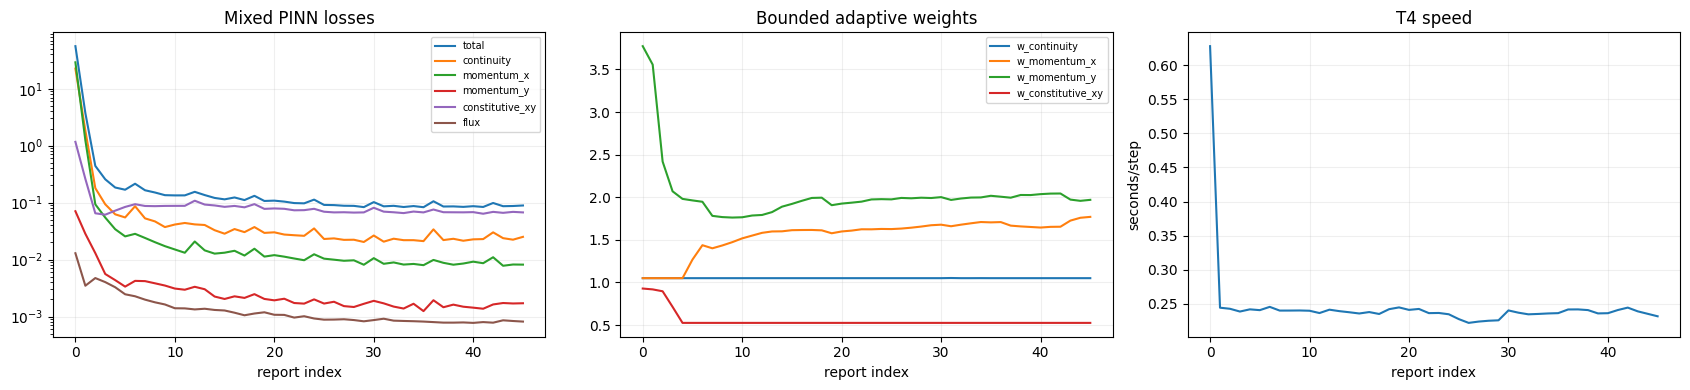

In [17]:
# V2 refinement curves and adaptive weights; still no CFD solution access.
history_table=pd.DataFrame(history);display(history_table.tail(12))
fig,axes=plt.subplots(1,3,figsize=(17,4))
for name in ("total","continuity","momentum_x","momentum_y","constitutive_xy","flux"):
    axes[0].semilogy(history_table[name].clip(lower=1e-12),label=name)
axes[0].set(title="Mixed PINN losses",xlabel="report index");axes[0].legend(fontsize=7);axes[0].grid(alpha=.2)
for name in ("w_continuity","w_momentum_x","w_momentum_y","w_constitutive_xy"):
    axes[1].plot(history_table[name],label=name)
axes[1].set(title="Bounded adaptive weights",xlabel="report index");axes[1].legend(fontsize=7);axes[1].grid(alpha=.2)
axes[2].plot(history_table["seconds_per_step"]);axes[2].set(title="T4 speed",ylabel="seconds/step",xlabel="report index");axes[2].grid(alpha=.2)
fig.tight_layout();fig.savefig(OUTPUT_DIR/"figures"/"mixed_training_diagnostics.png",dpi=170);plt.show()


In [18]:
# Freeze the v2 physics-selected model before the first CFD solution reload.
best_payload=torch.load(BEST,map_location=device,weights_only=False)
assert best_payload["used_cfd_labels_for_training"] is False
assert best_payload["gate_profiles_used"] is False
model.load_state_dict(best_payload["model"]);model.eval()
for parameter in model.parameters():parameter.requires_grad_(False)
MODEL_FROZEN=True
print(json.dumps(best_payload["diagnostic"],indent=2))
print("MODEL FROZEN - formal CFD validation may now begin")


{
  "continuity_rms": 0.11395224183797836,
  "momentum_x_rms": 0.08018018305301666,
  "momentum_y_rms": 0.03506936505436897,
  "constitutive_xx_rms": 0.00955246388912201,
  "constitutive_xy_rms": 0.1862543225288391,
  "constitutive_yy_rms": 0.009790739975869656,
  "flux_rms": 0.028555070981383324,
  "viscosity_min": 0.00375672266818583,
  "viscosity_max": 0.033652231097221375,
  "selection_score": 0.35827106614597143
}
MODEL FROZEN - formal CFD validation may now begin


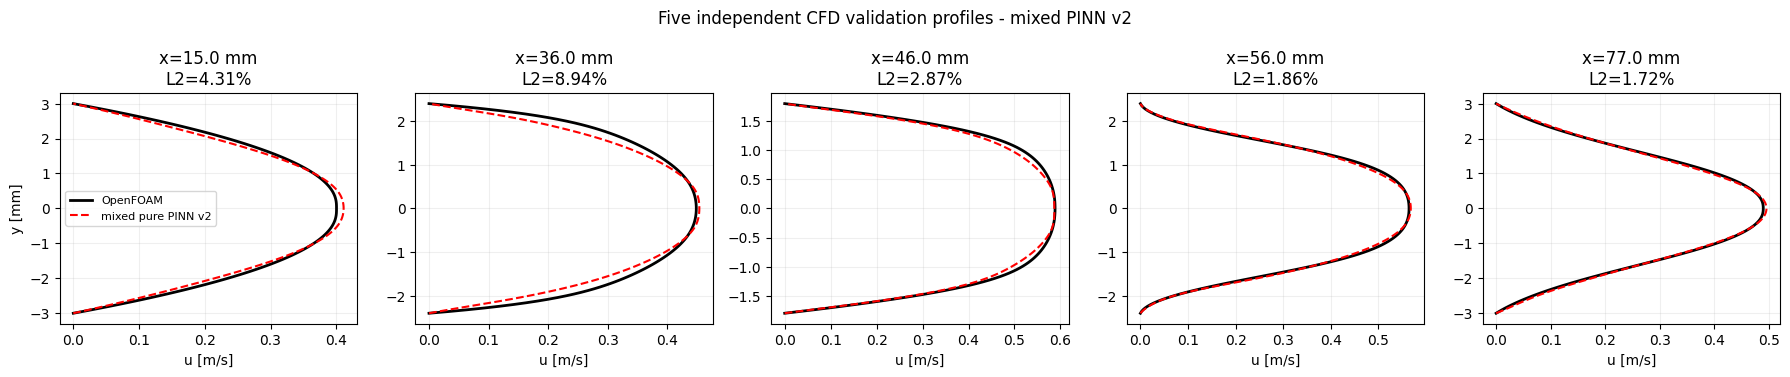

,profile,x_m,u_relative_l2_percent
0,profile_x015.csv,0.015,4.307967
1,profile_x036.csv,0.036,8.942356
2,profile_x046.csv,0.046,2.870661
3,profile_x056.csv,0.056,1.855073
4,profile_x077.csv,0.077,1.720877


mean=3.939% | maximum=8.942% | combined=4.556%
TASK 1.2 OFFICIAL GATE: PASS


In [19]:
# Official five-profile validation. First post-freeze access to CFD solution values.
assert MODEL_FROZEN
validation_case=load_planar_stenosis_case(ST40_DIR)
validation_profiles=[pd.read_csv(path) for path in profile_paths]
def predict(xy_np,chunk=8192):
    outputs=[]
    with torch.no_grad():
        for start in range(0,len(xy_np),chunk):
            points=torch.tensor(xy_np[start:start+chunk],device=device,dtype=DTYPE)
            outputs.append(model(points).cpu().numpy())
    return np.concatenate(outputs)

rows=[];all_pred=[];all_ref=[]
fig,axes=plt.subplots(1,5,figsize=(18,3.8))
for ax,path,profile in zip(axes,profile_paths,validation_profiles):
    xy=profile[["x","y"]].to_numpy(np.float32);prediction=predict(xy);reference_u=profile["u"].to_numpy()
    error=100*relative_l2_error(prediction[:,0],reference_u);x=float(profile["x"].median())
    rows.append(dict(profile=path.name,x_m=x,u_relative_l2_percent=error))
    all_pred.append(prediction[:,0]);all_ref.append(reference_u)
    ax.plot(reference_u,profile["y"]*1e3,"k-",lw=2,label="OpenFOAM")
    ax.plot(prediction[:,0],profile["y"]*1e3,"r--",label="mixed pure PINN v2")
    ax.set(xlabel="u [m/s]",title=f"x={1e3*x:.1f} mm\nL2={error:.2f}%");ax.grid(alpha=.2)
axes[0].set_ylabel("y [mm]");axes[0].legend(fontsize=8);fig.suptitle("Five independent CFD validation profiles - mixed PINN v2")
fig.tight_layout();fig.savefig(OUTPUT_DIR/"figures"/"mixed_velocity_profiles.png",dpi=180,bbox_inches="tight");plt.show()
profile_table=pd.DataFrame(rows);display(profile_table)
mean_error=float(profile_table["u_relative_l2_percent"].mean())
maximum_error=float(profile_table["u_relative_l2_percent"].max())
combined_error=100*relative_l2_error(np.concatenate(all_pred),np.concatenate(all_ref))
TASK_PASS=bool(len(rows)==5 and maximum_error<10.0)
print(f"mean={mean_error:.3f}% | maximum={maximum_error:.3f}% | combined={combined_error:.3f}%")
print("TASK 1.2 OFFICIAL GATE:","PASS" if TASK_PASS else "FAIL")


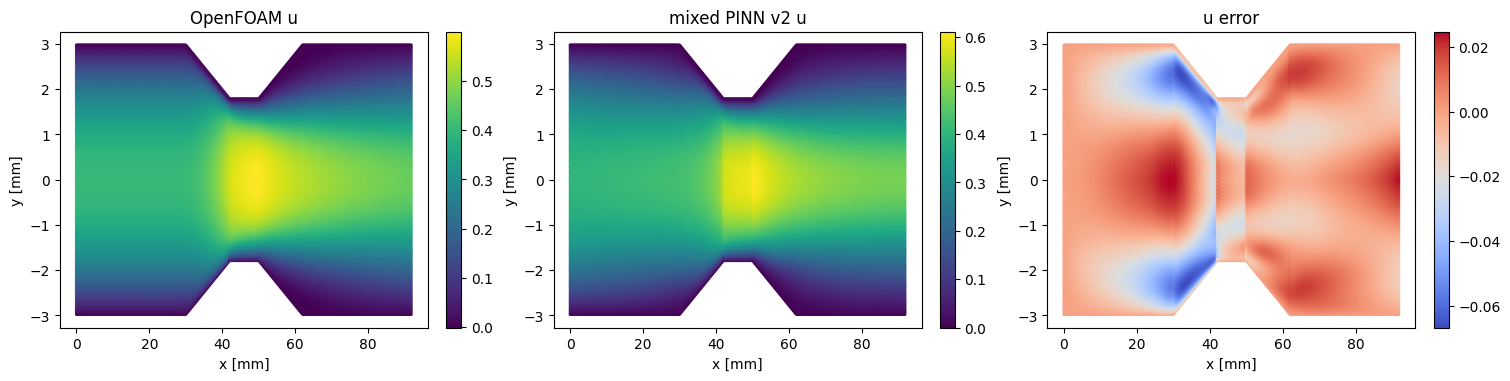

{
  "pressure_offset_pa": -0.020769005367335718,
  "u_relative_l2": 0.04881268272932638,
  "u_rmse": 0.017183681843164916,
  "u_max_absolute_error": 0.06675922870632114,
  "v_relative_l2": 0.3247285565225667,
  "v_rmse": 0.0016968041619870578,
  "v_max_absolute_error": 0.010096381418405218,
  "pressure_relative_l2": 0.39905637197583815,
  "pressure_rmse": 19.381761275622786,
  "pressure_max_absolute_error": 33.13630855614671
}


In [20]:
# Supplementary full-field audit (never used for model selection).
field=validation_case.field
xy=np.column_stack((field.x_m,field.y_m)).astype(np.float32)
mixed_prediction=predict(xy);prediction=mixed_prediction[:,:3]
reference=field.velocity_pressure();outlet_mask=field.x_m>field.x_m.max()-2*L/920
field_metrics=evaluate_planar_stenosis_field(prediction,reference,outlet_mask=outlet_mask).as_dict()
stride=max(1,len(xy)//30000);ids=np.arange(0,len(xy),stride)
fig,axes=plt.subplots(1,3,figsize=(15,3.7),constrained_layout=True)
for ax,values,title,cmap in zip(axes,(reference[ids,0],prediction[ids,0],prediction[ids,0]-reference[ids,0]),
                                ("OpenFOAM u","mixed PINN v2 u","u error"),("viridis","viridis","coolwarm")):
    scatter=ax.scatter(xy[ids,0]*1e3,xy[ids,1]*1e3,c=values,s=2,cmap=cmap)
    ax.set(xlabel="x [mm]",ylabel="y [mm]",title=title);fig.colorbar(scatter,ax=ax)
fig.savefig(OUTPUT_DIR/"figures"/"mixed_field_comparison.png",dpi=170);plt.show()
print(json.dumps(field_metrics,indent=2))


In [21]:
# Machine-readable gate result and reproducible handoff.
metrics=dict(case="P2D_ST40_Re500",training_type="pure_mixed_physics_refinement_v2",initialized_from_v1_physics_checkpoint=True,
    formulation="first_order_uvp_stress",fourier_features=False,
    used_cfd_labels_for_training=False,gate_profiles_used_for_training=False,
    profile_u_relative_l2_percent={row["profile"]:row["u_relative_l2_percent"] for row in rows},
    mean_profile_u_relative_l2_percent=mean_error,maximum_profile_u_relative_l2_percent=maximum_error,
    combined_profile_u_relative_l2_percent=combined_error,required_threshold_percent=10.0,
    all_five_profiles_below_threshold=TASK_PASS,task_1_2_passed=TASK_PASS,
    physics_only_checkpoint_score=best_physics_score,full_field_supplementary=field_metrics,
    git_commit=COMMIT,seed=SEED,gpu=GPU_NAME)
metrics_path=OUTPUT_DIR/"metrics"/"task_1_2_mixed_v2_metrics.json"
metrics_path.write_text(json.dumps(metrics,indent=2),encoding="utf-8")
best_payload["validation_result"]=metrics;atomic_save(best_payload,BEST)
print("checkpoint:",BEST);print("metrics:",metrics_path);print("figures:",OUTPUT_DIR/"figures")
print(json.dumps({"five_profiles":len(rows),"maximum_L2_percent":maximum_error,"task_1_2_passed":TASK_PASS},indent=2))


checkpoint: /kaggle/working/task_1_2_st40_mixed_pinn_v2/checkpoints/mixed_v2_best_physics.pt
metrics: /kaggle/working/task_1_2_st40_mixed_pinn_v2/metrics/task_1_2_mixed_v2_metrics.json
figures: /kaggle/working/task_1_2_st40_mixed_pinn_v2/figures
{
  "five_profiles": 5,
  "maximum_L2_percent": 8.94235585342284,
  "task_1_2_passed": true
}


## Definition of done

V2 passes only when all five profile errors are below 10%. The v1 artifact remains
unchanged for comparison. V2 starts from a pre-validation, physics-selected v1
checkpoint and uses a fresh optimizer; CFD values never enter the refinement loss
or model selection.
